# Exploratory Data Analysis (EDA) for Pneumonia Detection

This notebook fulfills the EDA requirements for the project. It covers dataset verification, class distribution, image samples, dimension statistics, and class imbalance mitigation strategies.

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data_dir = 'data/raw/chest_xray'
splits = ['train', 'val', 'test']
classes = ['NORMAL', 'PNEUMONIA']

colors = ['#2ca02c', '#d62728']

## 1. Train / Val / Test Split Verification
Verifying the number of images in each dataset split to ensure correct data loading.

In [4]:
split_counts = {}
for split in splits:
    split_counts[split] = {}
    for cls in classes:
        path = os.path.join(data_dir, split, cls)

        count = len(os.listdir(path)) if os.path.exists(path) else 0
        split_counts[split][cls] = count

print("Dataset Split Verification:")
for split, counts in split_counts.items():
    total = sum(counts.values())
    print(f"- {split.upper()}: {total} images (Normal: {counts['NORMAL']}, Pneumonia: {counts['PNEUMONIA']})")

Dataset Split Verification:
- TRAIN: 0 images (Normal: 0, Pneumonia: 0)
- VAL: 0 images (Normal: 0, Pneumonia: 0)
- TEST: 0 images (Normal: 0, Pneumonia: 0)


## 2. Class Distribution Visualization
Visualizing the count of 'Normal' vs 'Pneumonia' images in the training set to check for class imbalance.

/tmp/ipykernel_1976/3314206940.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=train_counts, palette=colors)


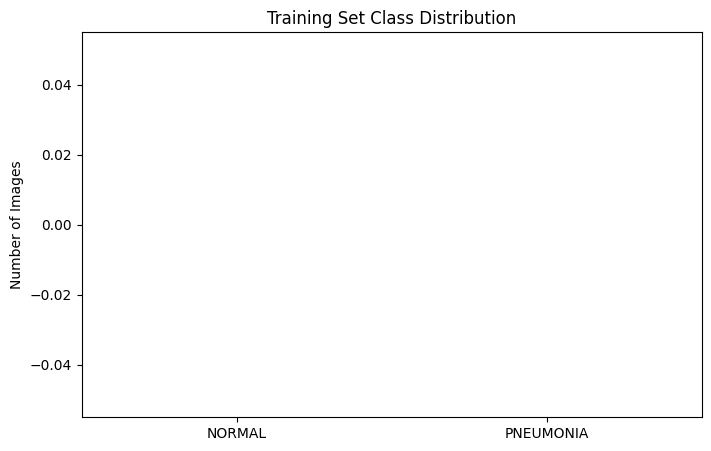

In [5]:
train_counts = [split_counts['train']['NORMAL'], split_counts['train']['PNEUMONIA']]

plt.figure(figsize=(8, 5))
sns.barplot(x=classes, y=train_counts, palette=colors)
plt.title('Training Set Class Distribution')
plt.ylabel('Number of Images')
plt.show()

## 3. Sample Image Grids
Displaying random samples from each class to understand the visual differences.

In [6]:
plt.figure(figsize=(12, 6))
for i, cls in enumerate(classes):
    path = os.path.join(data_dir, 'train', cls)
    if os.path.exists(path):
        sample_img_name = os.listdir(path)[0]
        img = cv2.imread(os.path.join(path, sample_img_name), cv2.IMREAD_GRAYSCALE)

        plt.subplot(1, 2, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(f'Class: {cls} | Shape: {img.shape}')
        plt.axis('off')
plt.show()

<Figure size 1200x600 with 0 Axes>

## 4. Image Dimension and Channel Statistics
Analyzing the width and height of images. (X-Rays are grayscale, so channel=1).

In [7]:
sample_size = 100
heights, widths = [], []

for cls in classes:
    path = os.path.join(data_dir, 'train', cls)
    if os.path.exists(path):
        images = os.listdir(path)[:sample_size]
        for img_name in images:
            img = cv2.imread(os.path.join(path, img_name))
            if img is not None:
                heights.append(img.shape[0])
                widths.append(img.shape[1])

print(f"Dimension Stats (based on {sample_size*2} samples):")
print(f"- Min Dimensions: {min(widths)}x{min(heights)}")
print(f"- Max Dimensions: {max(widths)}x{max(heights)}")
print(f"- Avg Dimensions: {int(np.mean(widths))}x{int(np.mean(heights))}")
print("- Channels: 1 (Grayscale images saved as 3-channel RGB in format, need to be converted to grayscale during training)")

Dimension Stats (based on 200 samples):


ValueError: min() iterable argument is empty

## 5. Pixel Intensity Distribution

This section analyzes the grayscale pixel intensity distribution of chest X-ray images to better understand brightness, contrast variation, and preprocessing needs before model training.

In [10]:

pixel_values = []
sample_size = 100  # sample images from each class

for cls in classes:
    path = os.path.join(data_dir, 'train', cls)

    if os.path.exists(path):
        images = sorted(os.listdir(path))[:sample_size]

        for img_name in images:
            img_path = os.path.join(path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is not None:
                pixel_values.extend(img.flatten())

pixel_values = np.array(pixel_values)

if pixel_values.size == 0:
    print("No pixel data could be loaded.")
    print("Check that the dataset exists under data/raw/chest_xray/")
    print("and that train/NORMAL and train/PNEUMONIA contain images.")
else:
    print("Pixel Intensity Statistics:")
    print(f"Mean Intensity: {np.mean(pixel_values):.2f}")
    print(f"Standard Deviation: {np.std(pixel_values):.2f}")
    print(f"Min Intensity: {np.min(pixel_values)}")
    print(f"Max Intensity: {np.max(pixel_values)}")

    plt.figure(figsize=(10, 6))
    plt.hist(pixel_values, bins=50)
    plt.title("Pixel Intensity Distribution")
    plt.xlabel("Pixel Intensity (0 = Black, 255 = White)")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

No pixel data could be loaded.
Check that the dataset exists under data/raw/chest_xray/
and that train/NORMAL and train/PNEUMONIA contain images.


## Observations

When the dataset is available locally, this section produces a grayscale histogram and summary statistics that help assess brightness and contrast variation across chest X-ray images.

These findings can support preprocessing decisions such as normalization and may also help identify whether contrast-aware augmentation should be considered later.

If no dataset is present in the current environment, the notebook reports the missing path instead of failing with an exception.